In [2]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

# Naive Bayes variants
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Other classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Text processing
import re
import nltk
from nltk.corpus import stopwords

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


Iris Dataset Shape: (150, 4)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      Setosa  
1       0      Setosa  
2       0      Setosa  
3       0      Setosa  
4       0      Setosa  

Target distribution:
target_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


/tmp/ipykernel_14345/2655108322.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_14345/2655108322.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


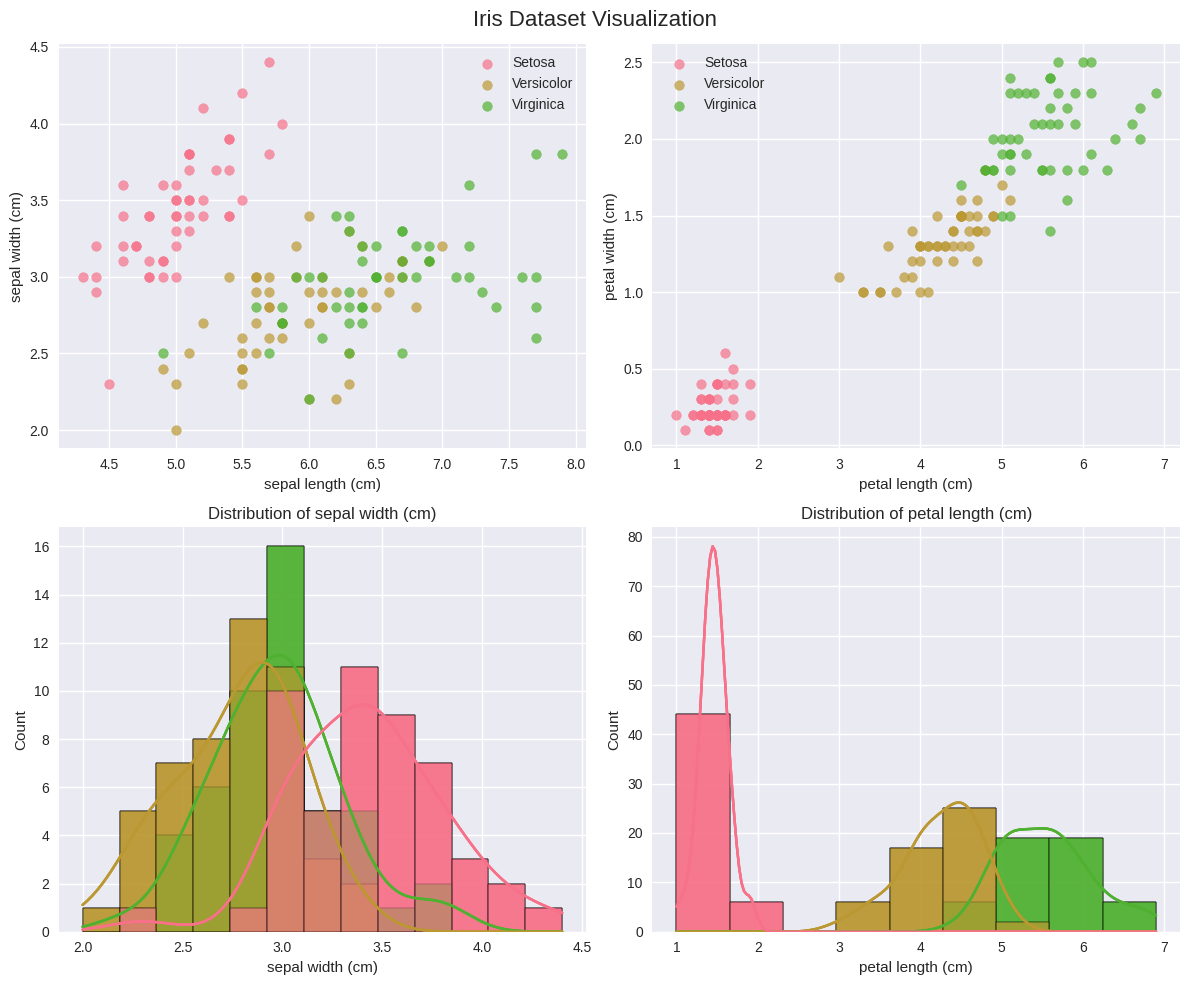


Training set size: 120 samples
Test set size: 30 samples

GaussianNB Accuracy on Iris: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



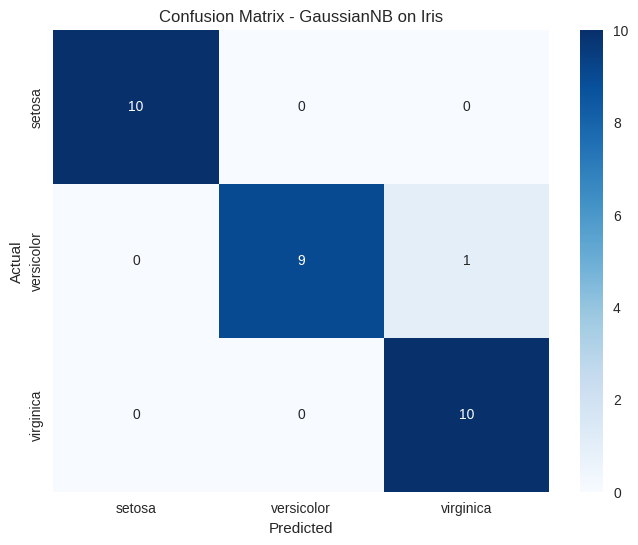


GaussianNB Parameters (Mean and Variance per class):

Class setosa:
  Mean: [4.985  3.415  1.4775 0.255 ]
  Variance: [0.092775   0.155275   0.02524375 0.012975  ]

Class versicolor:
  Mean: [5.93   2.75   4.2525 1.32  ]
  Variance: [0.2216     0.093      0.19149375 0.0341    ]

Class virginica:
  Mean: [6.61 2.98 5.58 2.04]
  Variance: [0.4574 0.1221 0.3236 0.0704]


In [3]:
# Load Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Convert to DataFrame for better visualization
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['target'] = y_iris
iris_df['target_name'] = iris_df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Iris Dataset Shape:", X_iris.shape)
print("\nFirst 5 rows:")
print(iris_df.head())

print("\nTarget distribution:")
print(iris_df['target_name'].value_counts())

# Visualize Iris dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = iris.feature_names
colors = ['blue', 'green', 'red']
targets = ['Setosa', 'Versicolor', 'Virginica']

for i, ax in enumerate(axes.flat):
    for j, target in enumerate(targets):
        mask = iris_df['target_name'] == target
        if i < 2:
            ax.scatter(iris_df[features[i*2]][mask], 
                      iris_df[features[i*2 + 1]][mask],
                      label=target, alpha=0.7)
            ax.set_xlabel(features[i*2])
            ax.set_ylabel(features[i*2 + 1])
        else:
            # For the last two plots, show distributions
            sns.histplot(data=iris_df, x=features[i-1], hue='target_name', 
                        ax=ax, kde=True, alpha=0.6)
            ax.set_title(f'Distribution of {features[i-1]}')
    ax.legend()

plt.suptitle('Iris Dataset Visualization', fontsize=16)
plt.tight_layout()
plt.show()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

# Train GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predictions
y_pred = gnb.predict(X_test)
y_pred_proba = gnb.predict_proba(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\nGaussianNB Accuracy on Iris: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - GaussianNB on Iris')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance via parameter means
print("\nGaussianNB Parameters (Mean and Variance per class):")
for i, class_name in enumerate(iris.target_names):
    print(f"\nClass {class_name}:")
    print(f"  Mean: {gnb.theta_[i]}")
    print(f"  Variance: {gnb.var_[i]}")

SMS Dataset Shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64
Percentage of spam: 13.41%


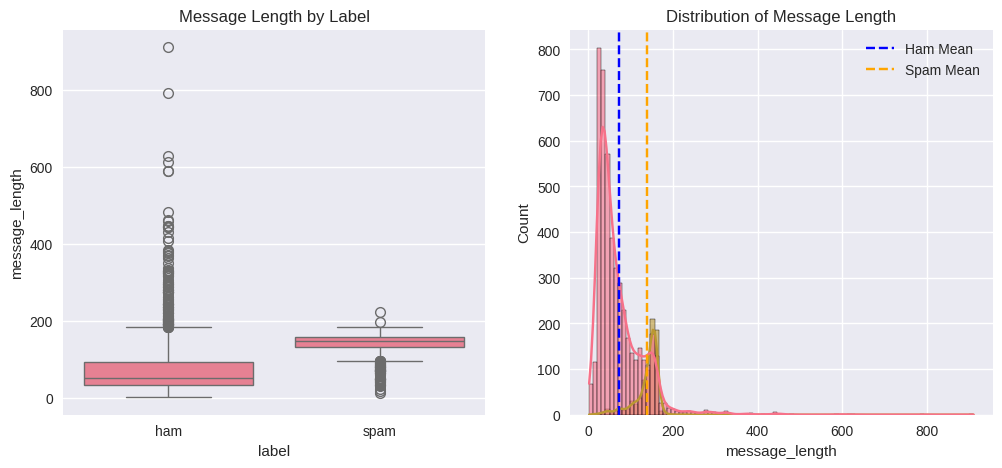


Sample of cleaned messages:
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in a wkly comp to win fa cup final ...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  

Feature matrix shape: (5572, 1000)
Training set: 4457 samples
Test set: 1115 samples

MultinomialNB Accuracy on SMS: 0.9731

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       966
        Spam       0.91      0.89      0.90   

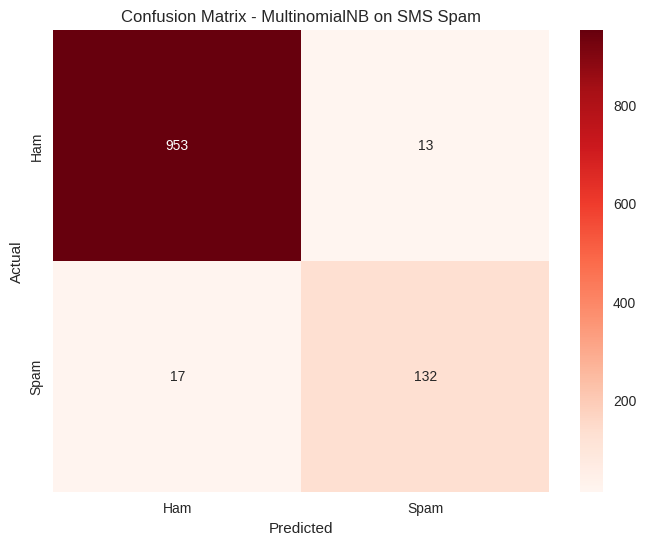


Top 10 words most indicative of SPAM:
  claim: 0.0147
  prize: 0.0104
  won: 0.0091
  tone: 0.0059
  guaranteed: 0.0059
  ppm: 0.0057
  landline: 0.0046
  tcs: 0.0045
  awarded: 0.0043
  pobox: 0.0040

Top 10 words most indicative of HAM:
  ltgt: 0.0118
  ill: 0.0103
  lor: 0.0068
  later: 0.0057
  thats: 0.0045
  amp: 0.0040
  ask: 0.0037
  said: 0.0035
  cos: 0.0035
  doing: 0.0035


In [4]:
# Load SMS Spam dataset
!wget -q https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv -O sms.tsv

# Read the data
sms_df = pd.read_csv('sms.tsv', sep='\t', header=None, names=['label', 'message'])
print("SMS Dataset Shape:", sms_df.shape)
print("\nFirst 5 rows:")
print(sms_df.head())

print("\nLabel distribution:")
print(sms_df['label'].value_counts())
print(f"Percentage of spam: {sms_df['label'].value_counts()['spam']/len(sms_df)*100:.2f}%")

# Visualize message length distribution
sms_df['message_length'] = sms_df['message'].str.len()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='label', y='message_length', data=sms_df)
plt.title('Message Length by Label')

plt.subplot(1, 2, 2)
sns.histplot(data=sms_df, x='message_length', hue='label', kde=True, alpha=0.6)
plt.title('Distribution of Message Length')
plt.axvline(x=sms_df[sms_df['label']=='ham']['message_length'].mean(), 
           color='blue', linestyle='--', label='Ham Mean')
plt.axvline(x=sms_df[sms_df['label']=='spam']['message_length'].mean(), 
           color='orange', linestyle='--', label='Spam Mean')
plt.legend()
plt.show()

# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Apply preprocessing
sms_df['clean_message'] = sms_df['message'].apply(preprocess_text)

print("\nSample of cleaned messages:")
print(sms_df[['message', 'clean_message']].head())

# Prepare features (using CountVectorizer)
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X_sms = vectorizer.fit_transform(sms_df['clean_message']).toarray()
y_sms = sms_df['label'].map({'ham': 0, 'spam': 1})

print(f"\nFeature matrix shape: {X_sms.shape}")

# Split data
X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(
    X_sms, y_sms, test_size=0.2, random_state=42, stratify=y_sms
)

print(f"Training set: {len(X_train_sms)} samples")
print(f"Test set: {len(X_test_sms)} samples")

# Train MultinomialNB
mnb = MultinomialNB(alpha=1.0)  # Laplace smoothing
mnb.fit(X_train_sms, y_train_sms)

# Predictions
y_pred_sms = mnb.predict(X_test_sms)
y_pred_proba_sms = mnb.predict_proba(X_test_sms)

# Evaluation
accuracy_sms = accuracy_score(y_test_sms, y_pred_sms)
print(f"\nMultinomialNB Accuracy on SMS: {accuracy_sms:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_sms, y_pred_sms, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm_sms = confusion_matrix(y_test_sms, y_pred_sms)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sms, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - MultinomialNB on SMS Spam')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Most important features (words) for spam detection
feature_names = vectorizer.get_feature_names_out()
spam_probs = mnb.feature_log_prob_[1]  # Log probabilities for spam
ham_probs = mnb.feature_log_prob_[0]   # Log probabilities for ham

# Get top spam-indicative words
top_spam_idx = np.argsort(spam_probs - ham_probs)[-10:][::-1]
top_ham_idx = np.argsort(ham_probs - spam_probs)[-10:][::-1]

print("\nTop 10 words most indicative of SPAM:")
for idx in top_spam_idx:
    print(f"  {feature_names[idx]}: {np.exp(spam_probs[idx]):.4f}")

print("\nTop 10 words most indicative of HAM:")
for idx in top_ham_idx:
    print(f"  {feature_names[idx]}: {np.exp(ham_probs[idx]):.4f}")